# 27 — Birth-scale-factor q-grid (`ncdm_quadrature_strategy = 5`)

Validates the `qm_acc_birth` daughter grid against the 20-decade Simpson grid (strategy 4).
Runs locally, no cluster: every run is cached in `accDM_scans/nb27_cache/`, so a rerun only
computes what is missing.

**Part A — golden parameters** (κ = 5, a_t = 0.13, f = 0.1, η = 0.1): strategy 5 at its
defaults and two tightened variants, against a 2001-bin strategy-4 reference, with the current
501-bin strategy 4 as the bar to match. Compares P(k) at z = 0 and 2, C_ℓ TT/EE, σ₈ and Ω_acc,
plus wall time.

**Part B — κ / a_t scan**: small κ, κ ≈ 1, production κ, large a_t (including a_t > 1).
Reference per point is strategy 5 with a much finer grid (`bpd = 75`, `tol = 1e-9`), cross-checked
against 501-bin strategy 4. Flags NaN in P(k) or C_ℓ.

**Runtime** (laptop, 4 threads, roughly 0.24 s per daughter bin): Part A about 12 min, dominated by
the 2001-bin reference; Part B about 25 min with `RUN_S4_IN_SCAN = True`, about 10 min without.
The setup cell prints the planned bin counts and a time estimate before anything runs.

In [11]:
import os, time, pickle
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

CACHE_DIR = os.path.join('accDM_scans', 'nb27_cache')
os.makedirs(CACHE_DIR, exist_ok=True)
FORCE = False            # True: recompute even when a cached run exists
RUN_SCAN = True          # Part B
RUN_S4_IN_SCAN = True    # Part B: also run 501-bin strategy 4 per point (about 2 min each)
SEC_PER_BIN = 0.24       # rough cost per daughter bin, used only for the time estimate

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

# --- base cosmology (as nb1 golden) ---
omega_b, omega_cdm0 = 0.022383, 0.12011
A_s, n_s, tau_reio, H0 = 2.1005829616811546e-9, 0.96605, 0.0543, 67.32
base_params = {'omega_b': omega_b, 'omega_cdm': omega_cdm0, 'H0': H0,
               'A_s': A_s, 'n_s': n_s, 'tau_reio': tau_reio}
MASS, F_ACC, ETA = 1e16, 0.1, 0.1
A_REC = 1.0 / (1.0 + 1090.0)

LMAX = 2500
K_PK = np.logspace(-3, 1, 60)     # 1/Mpc
Z_PK = [0.0, 2.0]
K_CUTS = [1.0, 10.0]              # report max |dP/P| for k <= each cut


def accdm_params(kappa, a_t, grid):
    """Golden accDM model; grid = {'strategy': 4|5, optional 'bins', 'tol', 'bpd'}."""
    ocdm = omega_cdm0 * (1 + F_ACC*(1 - A_REC**kappa)/(1 + (A_REC/a_t)**kappa))**(-1)
    p = dict(base_params)
    p.update({'output': 'tCl,pCl,mPk', 'l_max_scalars': LMAX,
              'P_k_max_1/Mpc': 10.0, 'z_max_pk': max(Z_PK),
              'omega_cdm': ocdm,
              'vary_Gamma_acc': 'yes', 'kappa_acc': kappa, 'a_t_acc': a_t,
              'f_acc': F_ACC, 'eta_acc': ETA,
              'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
              'N_ncdm': 2, 'deg_ncdm': '3, 1',
              'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
              'T_ncdm': '0.711, 1', 'N_ur': 0.0046,
              'ncdm_quadrature_strategy': '0, {}'.format(grid['strategy']),
              'reionization_z_start_max': 80, 'evolver': 0,
              'background_Nloga': 40000, 'gauge': 'synchronous',
              'ncdm_fluid_approximation': 3,
              })              # exact hierarchy
    if 'bins' in grid:
        p['ncdm_N_momentum_bins'] = '15, {}'.format(grid['bins'])
    if 'tol' in grid:
        p['accdm_q_number_tol'] = grid['tol']
    if 'bpd' in grid:
        p['accdm_q_bins_per_decade'] = grid['bpd']
    return p


# --- python copy of the C grid rule (background_acc_a_min + input.c), for planning ---
def born_fraction(a, kappa, a_t):
    return 1.0 if a >= 1 else 1 - (1 - a**kappa)/(1 + (a/a_t)**kappa)

def a_min(kappa, a_t, eps=1e-6):
    kappa = 0.99999 if kappa == 1.0 else kappa
    lo, hi = np.log(1e-14), 0.0
    if born_fraction(np.exp(lo), kappa, a_t) >= eps:
        return 1e-14
    for _ in range(100):
        mid = 0.5*(lo + hi)
        if born_fraction(np.exp(mid), kappa, a_t) < eps:
            lo = mid
        else:
            hi = mid
        if hi - lo < 1e-10:
            break
    return np.exp(lo)

def planned_bins(kappa, a_t, grid):
    if 'bins' in grid:
        n = grid['bins']
    else:
        amin = a_min(kappa, a_t, grid.get('tol', 1e-6))
        n = max(3, int(np.ceil(grid.get('bpd', 25.0)*np.log10(1/amin))) + 1)
    return n + (n % 2 == 0)


def run(tag, params):
    """Cache-first CLASS run; returns P(k), C_l, sigma8, Omega_acc and wall time."""
    path = os.path.join(CACHE_DIR, tag + '.pkl')
    if os.path.exists(path) and not FORCE:
        with open(path, 'rb') as fh:
            return pickle.load(fh)
    print('[run ] {} ...'.format(tag), flush=True)
    M = Class(); M.set(params)
    t0 = time.perf_counter(); M.compute(); seconds = time.perf_counter() - t0
    cl = M.raw_cl(LMAX)
    bg = M.get_background()
    rec = {'pk': {z: np.array([M.pk(k, z) for k in K_PK]) for z in Z_PK},
           'tt': np.array(cl['tt'][2:]), 'ee': np.array(cl['ee'][2:]),
           'sigma8': M.sigma8(),
           'Omega_acc': bg['(.)rho_ncdm[1]'][-1] / bg['(.)rho_crit'][-1],
           'seconds': seconds}
    M.struct_cleanup(); M.empty()
    with open(path, 'wb') as fh:
        pickle.dump(rec, fh)
    print('[done] {} {:.0f} s'.format(tag, seconds), flush=True)
    return rec


def has_nan(rec):
    arrays = list(rec['pk'].values()) + [rec['tt'], rec['ee']]
    return any(not np.all(np.isfinite(x)) for x in arrays)

def compare(rec, ref):
    """Max relative deviations of rec from ref."""
    out = {}
    for z in Z_PK:
        rel = np.abs(rec['pk'][z]/ref['pk'][z] - 1)
        for kc in K_CUTS:
            out['pk_z{:g}_k{:g}'.format(z, kc)] = np.max(rel[K_PK <= kc])
    out['tt'] = np.max(np.abs(rec['tt']/ref['tt'] - 1))
    out['ee'] = np.max(np.abs(rec['ee']/ref['ee'] - 1))
    out['sigma8'] = abs(rec['sigma8']/ref['sigma8'] - 1)
    out['Omega_acc'] = abs(rec['Omega_acc']/ref['Omega_acc'] - 1)
    return out

## Part A — golden parameters

Reference: strategy 4 with 2001 bins. Target: strategy 5 at its defaults matches the 501-bin
strategy 4 (current production) in accuracy at a fraction of the time. From the prototype,
expect max |ΔP/P| ≈ 1.2e-3 (k ≤ 1) and ≈ 1.9e-3 (k ≤ 10) at about 10× speed-up.

In [2]:
KAPPA0, A_T0 = 12.1, 0.133
GOLDEN_GRIDS = {                                   # tag: (label, grid)
    's4_2001':  ('S4, 2001 bins (reference)', {'strategy': 4, 'bins': 2001}),
    's4_501':   ('S4, 501 bins (production)', {'strategy': 4, 'bins': 501}),
    's5':       ('S5 default',                {'strategy': 5}),
    's5_bpd30': ('S5, 30 bins/decade',        {'strategy': 5, 'bpd': 30.0}),
    's5_bpd40': ('S5, 40 bins/decade',        {'strategy': 5, 'bpd': 40.0}),
    's5_bpd50': ('S5, 50 bins/decade',        {'strategy': 5, 'bpd': 50.0}),
    's5_bpd100': ('S5, 100 bins/decade',        {'strategy': 5, 'bpd': 100.0}),
    's5_bpd150': ('S5, 150 bins/decade',        {'strategy': 5, 'bpd': 150.0}),
    's5_bpd250': ('S5, 250 bins/decade',        {'strategy': 5, 'bpd': 250.0}),
    's5_tol8':  ('S5, tol 1e-8',              {'strategy': 5, 'tol': 1e-8}),
}

print('a_min (tol 1e-6) = {:.3e}'.format(a_min(KAPPA0, A_T0)))
total = 0.0
for tag, (label, grid) in GOLDEN_GRIDS.items():
    n = planned_bins(KAPPA0, A_T0, grid)
    total += n*SEC_PER_BIN
    print('  {:28s} {:5d} bins   ~{:4.0f} s'.format(label, n, n*SEC_PER_BIN))
print('Part A estimate (uncached): ~{:.0f} min'.format(total/60))

a_min (tol 1e-6) = 4.246e-02
  S4, 2001 bins (reference)     2001 bins   ~ 480 s
  S4, 501 bins (production)      501 bins   ~ 120 s
  S5 default                      37 bins   ~   9 s
  S5, 30 bins/decade              43 bins   ~  10 s
  S5, 40 bins/decade              57 bins   ~  14 s
  S5, 50 bins/decade              71 bins   ~  17 s
  S5, 100 bins/decade            139 bins   ~  33 s
  S5, 150 bins/decade            207 bins   ~  50 s
  S5, 250 bins/decade            345 bins   ~  83 s
  S5, tol 1e-8                    41 bins   ~  10 s
Part A estimate (uncached): ~14 min


In [3]:
golden = {tag: run('golden_{}'.format(tag), accdm_params(KAPPA0, A_T0, grid))
          for tag, (label, grid) in GOLDEN_GRIDS.items()}
ref = golden['s4_2001']

cols = ['pk_z0_k1', 'pk_z0_k10', 'pk_z2_k1', 'pk_z2_k10', 'tt', 'ee', 'sigma8', 'Omega_acc']
print('{:28s} {:>6s} {:>7s} {:>4s} '.format('grid', 'time', 'speedup', 'NaN')
      + ' '.join('{:>10s}'.format(c) for c in cols))
for tag, (label, grid) in GOLDEN_GRIDS.items():
    rec = golden[tag]
    dev = compare(rec, ref)
    print('{:28s} {:5.0f}s {:6.1f}x {:>4s} '.format(
              label, rec['seconds'], golden['s4_501']['seconds']/rec['seconds'],
              'YES' if has_nan(rec) else 'no')
          + ' '.join('{:10.2e}'.format(dev[c]) for c in cols))
print('speed-up is relative to S4, 501 bins')

grid                           time speedup  NaN   pk_z0_k1  pk_z0_k10   pk_z2_k1  pk_z2_k10         tt         ee     sigma8  Omega_acc
S4, 2001 bins (reference)      925s    0.1x   no   0.00e+00   0.00e+00   0.00e+00   0.00e+00   0.00e+00   0.00e+00   0.00e+00   0.00e+00
S4, 501 bins (production)      109s    1.0x   no   3.49e-03   3.49e-03   6.27e-03   9.46e-03   3.47e-03   1.43e-03   1.19e-04   1.20e-03
S5 default                      14s    8.0x   no   1.30e-03   3.80e-03   4.77e-03   9.09e-03   7.53e-04   6.68e-04   1.25e-04   7.98e-07
S5, 30 bins/decade               9s   11.8x   no   2.54e-03   3.05e-03   6.50e-03   9.47e-03   2.75e-03   9.16e-04   1.79e-04   2.37e-04
S5, 40 bins/decade              11s   10.1x   no   1.92e-03   4.73e-03   1.42e-02   1.42e-02   6.13e-04   6.85e-04   1.08e-04   8.39e-06
S5, 50 bins/decade              13s    8.5x   no   1.30e-03   3.80e-03   4.77e-03   9.09e-03   7.53e-04   6.68e-04   1.25e-04   7.98e-07
S5, 100 bins/decade             23s    4.

In [4]:
dev_s5, dev_s4 = compare(golden['s5'], ref), compare(golden['s4_501'], ref)
checks = [
    ('no NaN in any golden run', not any(has_nan(r) for r in golden.values())),
    ('S5 P(k) z=0, k<=1 within 1.5x of S4-501',  dev_s5['pk_z0_k1']  <= 1.5*dev_s4['pk_z0_k1']),
    ('S5 P(k) z=0, k<=10 within 1.5x of S4-501', dev_s5['pk_z0_k10'] <= 1.5*dev_s4['pk_z0_k10']),
    ('S5 C_l TT/EE within 1e-3 of reference',    max(dev_s5['tt'], dev_s5['ee']) <= 1e-3),
    ('S5 Omega_acc within 1e-4 of reference',     dev_s5['Omega_acc'] <= 1e-4),
    ('S5 at least 5x faster than S4-501',         golden['s4_501']['seconds'] >= 5*golden['s5']['seconds']),
]
for name, ok in checks:
    print('{}  {}'.format('PASS' if ok else 'FAIL', name))

PASS  no NaN in any golden run
PASS  S5 P(k) z=0, k<=1 within 1.5x of S4-501
PASS  S5 P(k) z=0, k<=10 within 1.5x of S4-501
PASS  S5 C_l TT/EE within 1e-3 of reference
PASS  S5 Omega_acc within 1e-4 of reference
PASS  S5 at least 5x faster than S4-501


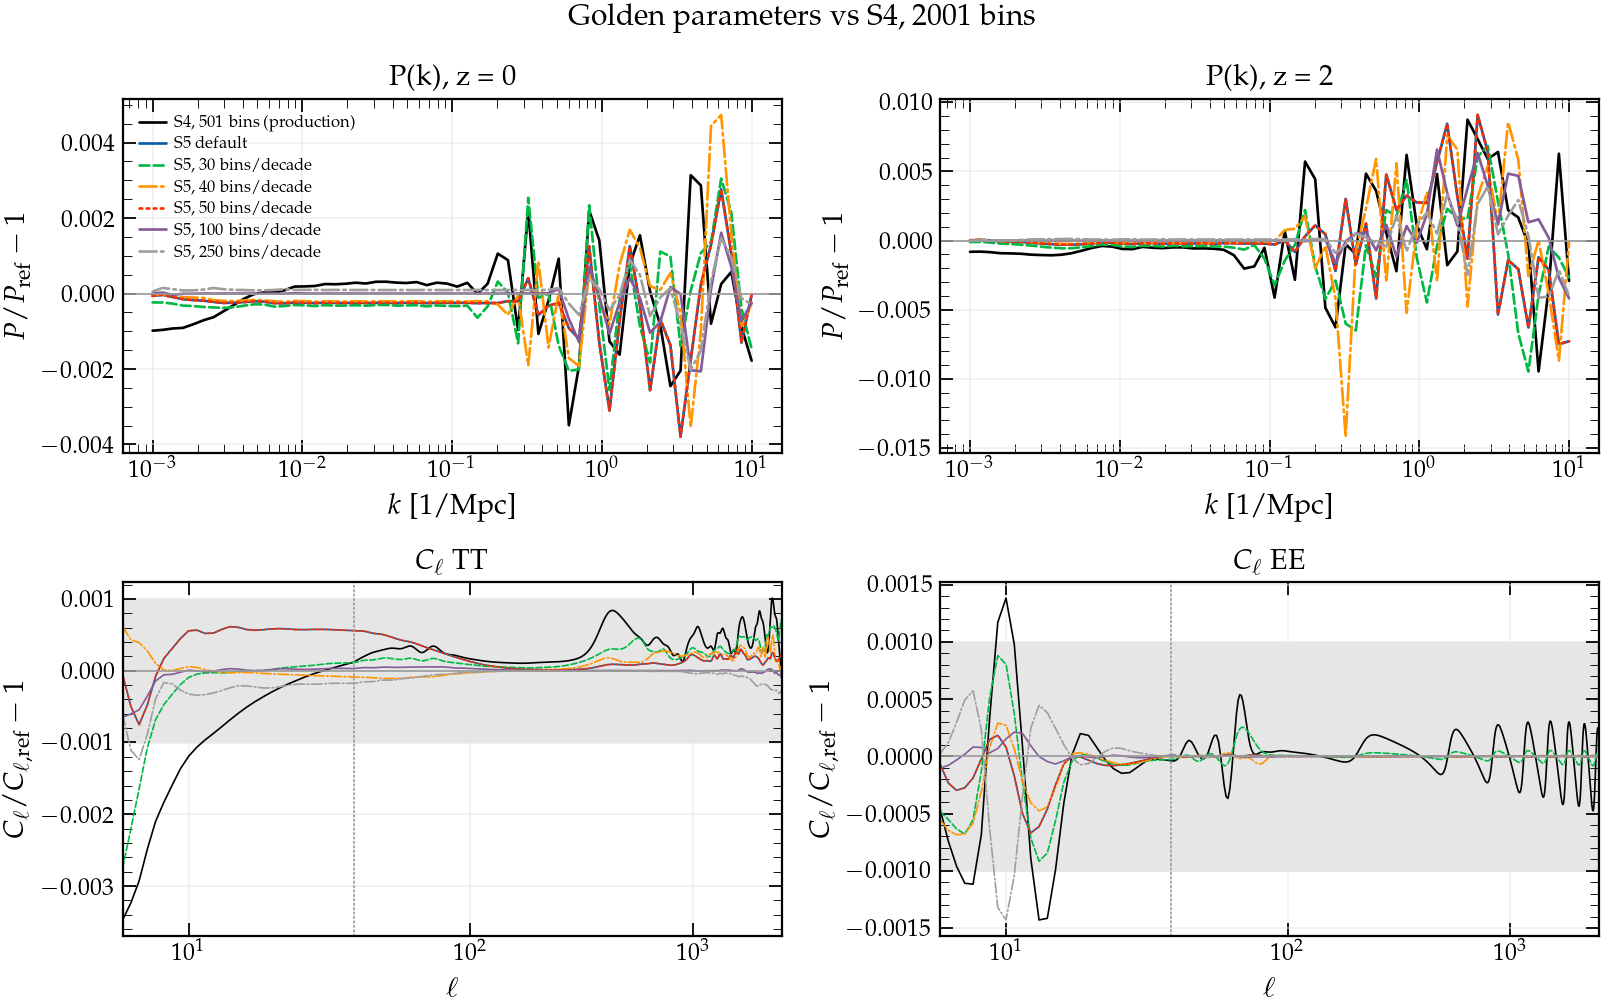

In [5]:
import figkit as fk

fk.use('quick')

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
styles = {'s4_501': ('k', '-'), 
          's5': ('C0', '-'), 
          's5_bpd30': ('C1', '--'), 
          's5_bpd40': ('C2', '-.'), 
          's5_bpd50': ('C3', ':'),
          's5_bpd100': ('C4', '-'),
        #   's5_bpd150': ('C5', '--'),
          's5_bpd250': ('C6', '-.'),
        #   's5_tol8': ('C7', ':')
          }
for ax, z in zip(axes[0], Z_PK):
    for tag, (color, ls) in styles.items():
        ax.semilogx(K_PK, golden[tag]['pk'][z]/ref['pk'][z] - 1, color=color, ls=ls,
                    label=GOLDEN_GRIDS[tag][0])
    ax.axhline(0, color='0.6', lw=0.8)
    ax.set_xlabel(r'$k$ [1/Mpc]'); ax.set_ylabel(r'$P / P_\mathrm{ref} - 1$')
    ax.set_title('P(k), z = {:g}'.format(z))
    ax.grid(which='major', color='0.9', lw=0.8, ls='-')
axes[0, 0].legend(fontsize=8)
ell = np.arange(2, LMAX + 1)
for ax, spec in zip(axes[1], ('tt', 'ee')):
    for tag, (color, ls) in styles.items():
        ax.plot(ell, golden[tag][spec]/ref[spec] - 1, color=color, ls=ls, lw=0.8)
    ax.axhline(0, color='0.6', lw=0.8)
    # ax.set_xscale('log')
    ax.set_xscale('symlog', linthresh=30)
    ax.axvline(30, color='0.6', lw=0.8, ls=':')
    ax.set_xlim(2, LMAX)
    ax.fill_between(ell, -1e-3, 1e-3, color='0.9', zorder=-1)
    ax.set_xlabel(r'$\ell$'); ax.set_ylabel(r'$C_\ell / C_{\ell,\mathrm{ref}} - 1$')
    ax.set_title(r'$C_\ell$ {}'.format(spec.upper()))
    ax.grid(which='major', color='0.9', lw=0.8, ls='-')
fig.suptitle('Golden parameters vs S4, 2001 bins')
fig.tight_layout()

## Part B — κ / a_t scan

Each point runs strategy 5 at its defaults and a fine strategy-5 reference (`bpd = 75`,
`tol = 1e-9`); with `RUN_S4_IN_SCAN` also 501-bin strategy 4. Strategy 5 should converge to the
fine reference, and the fine reference should agree with strategy 4 at the ~1e-3 level of the
501-bin grid. κ = 1 exercises the code's 0.99999 substitution; a_t = 3 puts the transition after today.
Small κ gives a_min near the 1e-14 floor and the most bins.

In [6]:
SCAN = [(5.0, 0.13), (0.5, 0.13), (1.0, 0.13), (2.0, 0.13), (6.0, 0.13),
        (12.1, 0.133), (5.0, 0.5), (5.0, 1.0), (5.0, 3.0)]
SCAN_GRIDS = {'s5': {'strategy': 5},
              's5_fine': {'strategy': 5, 'bpd': 75.0, 'tol': 1e-9}}
if RUN_S4_IN_SCAN:
    SCAN_GRIDS['s4_501'] = {'strategy': 4, 'bins': 501}

def point_tag(kappa, a_t, grid_tag):
    return 'scan_k{:g}_at{:g}_{}'.format(kappa, a_t, grid_tag)

total = 0.0
print('{:>6s} {:>6s} {:>10s} '.format('kappa', 'a_t', 'a_min') + ' '.join('{:>8s}'.format(g) for g in SCAN_GRIDS))
for kappa, a_t in SCAN:
    bins = [planned_bins(kappa, a_t, g) for g in SCAN_GRIDS.values()]
    todo = [n for n, g in zip(bins, SCAN_GRIDS)
            if FORCE or not os.path.exists(os.path.join(CACHE_DIR, point_tag(kappa, a_t, g) + '.pkl'))]
    total += sum(todo)*SEC_PER_BIN
    print('{:6g} {:6g} {:10.2e} '.format(kappa, a_t, a_min(kappa, a_t)) + ' '.join('{:8d}'.format(n) for n in bins))
print('Part B estimate for uncached runs: ~{:.0f} min'.format(total/60))

 kappa    a_t      a_min       s5  s5_fine   s4_501
     5   0.13   8.20e-03       55      203      501
   0.5   0.13   7.02e-14      331     1051      501
     1   0.13   1.15e-07      175      747      501
     2   0.13   1.29e-04       99      407      501
     6   0.13   1.30e-02       49      181      501
  12.1  0.133   4.25e-02       37      123      501
     5    0.5   3.14e-02       39      159      501
     5      1   5.49e-02       33      141      501
     5      3   6.30e-02       33      137      501
Part B estimate for uncached runs: ~0 min


In [7]:
scan = {}
if RUN_SCAN:
    for kappa, a_t in SCAN:
        for grid_tag, grid in SCAN_GRIDS.items():
            try:
                scan[(kappa, a_t, grid_tag)] = run(point_tag(kappa, a_t, grid_tag), accdm_params(kappa, a_t, grid))
            except Exception as err:                 # CLASS errors are findings here, not crashes
                print('[FAIL] kappa={:g} a_t={:g} {}: {}'.format(kappa, a_t, grid_tag, err))
                scan[(kappa, a_t, grid_tag)] = None

    print('{:>6s} {:>6s} {:>6s} {:>4s} {:>10s} {:>10s} {:>10s} {:>10s}'.format(
        'kappa', 'a_t', 't_S5', 'NaN', 'S5 k<=1', 'S5 k<=10', 'S5 TT', 'S4 k<=1'))
    for kappa, a_t in SCAN:
        s5, fine = scan.get((kappa, a_t, 's5')), scan.get((kappa, a_t, 's5_fine'))
        s4 = scan.get((kappa, a_t, 's4_501'))
        if s5 is None or fine is None:
            print('{:6g} {:6g}   run failed'.format(kappa, a_t)); continue
        d5 = compare(s5, fine)
        d4 = compare(s4, fine)['pk_z0_k1'] if s4 is not None else np.nan
        nan = any(has_nan(r) for r in (s5, fine, s4) if r is not None)
        print('{:6g} {:6g} {:5.0f}s {:>4s} {:10.2e} {:10.2e} {:10.2e} {:10.2e}'.format(
            kappa, a_t, s5['seconds'], 'YES' if nan else 'no',
            d5['pk_z0_k1'], d5['pk_z0_k10'], d5['tt'], d4))
    print('deviations are relative to the fine strategy-5 run of the same point')

 kappa    a_t   t_S5  NaN    S5 k<=1   S5 k<=10      S5 TT    S4 k<=1
     5   0.13    20s   no   1.01e-03   2.30e-03   3.22e-04   1.74e-03
   0.5   0.13   151s   no   2.62e-03   2.62e-03   1.78e-03   3.84e-03
     1   0.13    73s   no   2.49e-03   2.49e-03   1.75e-04   5.02e-03
     2   0.13    43s   no   2.72e-03   3.47e-03   1.59e-03   3.84e-03
     6   0.13    19s   no   7.93e-04   3.09e-03   4.20e-04   1.86e-03
  12.1  0.133    14s   no   1.65e-03   3.61e-03   1.89e-03   2.60e-03
     5    0.5    13s   no   1.34e-02   1.34e-02   7.60e-04   1.91e-02
     5      1    12s   no   3.31e-02   4.03e-02   7.88e-04   3.91e-02
     5      3    12s   no   3.33e-02   3.77e-02   5.90e-04   6.62e-02
deviations are relative to the fine strategy-5 run of the same point


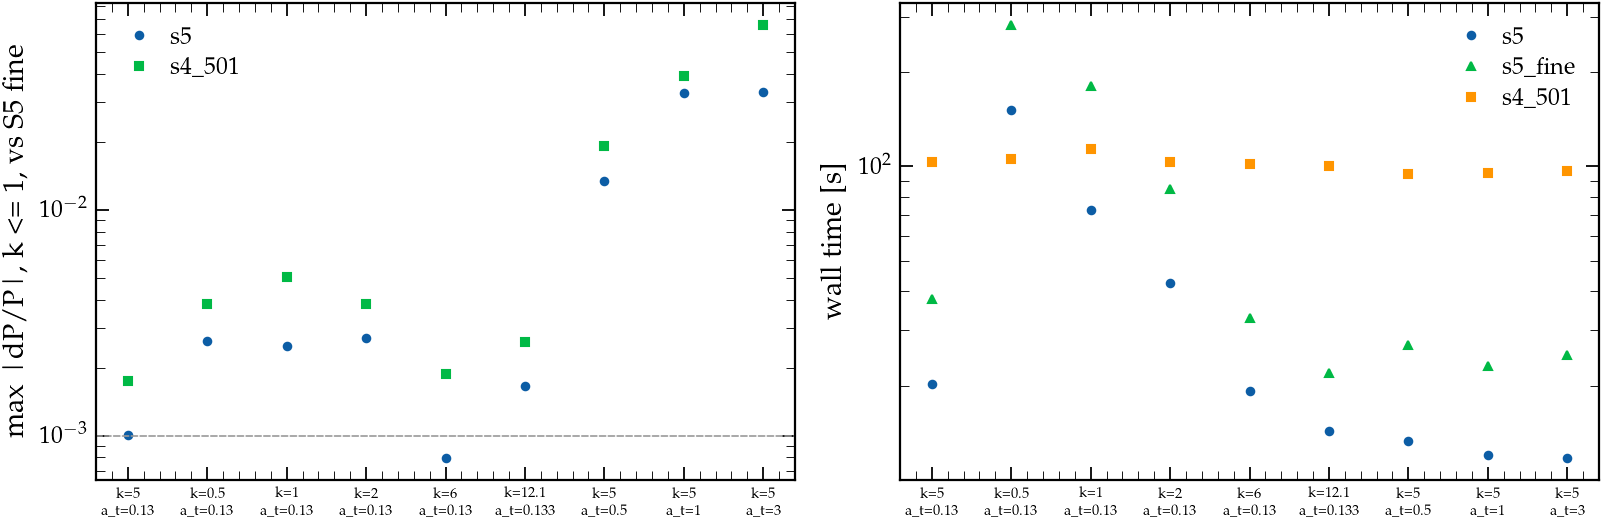

In [8]:
if RUN_SCAN:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    labels = ['k={:g}\na_t={:g}'.format(k, a) for k, a in SCAN]
    x = np.arange(len(SCAN))
    for grid_tag, marker in (('s5', 'o'), ('s4_501', 's')):
        errs = []
        for kappa, a_t in SCAN:
            rec, fine = scan.get((kappa, a_t, grid_tag)), scan.get((kappa, a_t, 's5_fine'))
            errs.append(compare(rec, fine)['pk_z0_k1'] if rec is not None and fine is not None else np.nan)
        axes[0].semilogy(x, errs, marker, label=grid_tag)
    axes[0].axhline(1e-3, color='0.6', ls='--', lw=0.8)
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=7)
    axes[0].set_ylabel('max |dP/P|, k <= 1, vs S5 fine'); axes[0].legend()
    for grid_tag, marker in (('s5', 'o'), ('s5_fine', '^'), ('s4_501', 's')):
        secs = [scan[(k, a, grid_tag)]['seconds'] if scan.get((k, a, grid_tag)) else np.nan for k, a in SCAN]
        axes[1].semilogy(x, secs, marker, label=grid_tag)
    axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=7)
    axes[1].set_ylabel('wall time [s]'); axes[1].legend()
    fig.tight_layout()

In [12]:
LADDER = [25.0, 50.0, 100.0, 200.0, 400.0]
for a_t in (0.5, 1.0, 3.0):
    recs = {bpd: run(point_tag(5.0, a_t, 's5_bpd{:g}'.format(bpd)),
                     accdm_params(5.0, a_t, {'strategy': 5, 'bpd': bpd})) for bpd in LADDER}
    top = recs[LADDER[-1]]
    print('a_t = {:g}  (reference: {:g} bins/decade)'.format(a_t, LADDER[-1]))
    for bpd in LADDER[:-1]:
        d = compare(recs[bpd], top)
        print('  bpd {:5g}  Pk k<=1 {:.2e}  Omega_acc {:.2e}  sigma8 {:.2e}  {:4.0f}s'.format(
            bpd, d['pk_z0_k1'], d['Omega_acc'], d['sigma8'], recs[bpd]['seconds']))

a_t = 0.5  (reference: 400 bins/decade)
  bpd    25  Pk k<=1 1.93e-02  Omega_acc 4.37e-06  sigma8 3.56e-04     8s
  bpd    50  Pk k<=1 9.78e-03  Omega_acc 2.69e-07  sigma8 9.54e-05    14s
  bpd   100  Pk k<=1 1.31e-02  Omega_acc 1.67e-08  sigma8 3.80e-05    27s
  bpd   200  Pk k<=1 3.48e-03  Omega_acc 1.01e-09  sigma8 3.59e-05    52s
a_t = 1  (reference: 400 bins/decade)
  bpd    25  Pk k<=1 3.77e-02  Omega_acc 6.34e-06  sigma8 4.91e-03     7s
  bpd    50  Pk k<=1 2.31e-02  Omega_acc 3.70e-07  sigma8 1.50e-03    13s
  bpd   100  Pk k<=1 1.41e-02  Omega_acc 2.27e-08  sigma8 8.03e-05    22s
  bpd   200  Pk k<=1 9.42e-03  Omega_acc 1.37e-09  sigma8 2.51e-04    40s
[run ] scan_k5_at3_s5_bpd100 ...
[done] scan_k5_at3_s5_bpd100 21 s
[run ] scan_k5_at3_s5_bpd200 ...
[done] scan_k5_at3_s5_bpd200 39 s
[run ] scan_k5_at3_s5_bpd400 ...
[done] scan_k5_at3_s5_bpd400 81 s
a_t = 3  (reference: 400 bins/decade)
  bpd    25  Pk k<=1 5.50e-02  Omega_acc 2.10e-04  sigma8 9.23e-03     7s
  bpd    50  Pk k

[run ] scan_k5_at1_s5_bpd100_tol1e-05 ...
[done] scan_k5_at1_s5_bpd100_tol1e-05 19 s
tol 1e-05: max|dP/P| vs default tol 1.43e-04, sigma8 8.70e-08, 19s
[run ] scan_k5_at1_s5_bpd100_tol1e-07 ...


CosmoComputationError: 

Error in Class: operator()(L:952) :error in perturbations_solve(ppr, pba, pth, ppt, index_md, index_ic, index_k, &pw);
=>perturbations_solve(L:3253) :error in generic_evolver(perturbations_derivs, interval_limit[index_interval], interval_limit[index_interval+1], ppw->pv->y, ppw->pv->used_in_sources, ppw->pv->pt_size, &ppaw, ppr->tol_perturbations_integration, ppr->smallest_allowed_variation, perturbations_timescale, ppr->perturbations_integration_stepsize, ppt->tau_sampling, tau_actual_size, perturbations_sources, perhaps_print_variables, ppt->error_message);
=>evolver_rk(L:110) :error in generic_integrator(derivs, x1, x2, y, parameters_and_workspace_for_derivs, tolerance, x1*minimum_variation, &gi);
=>generic_integrator(L:117) :condition (fabs(hnext/x1) <= hmin) is true; Step size too small: step:7.87961e-13, minimum:2.0409e-12, in interval: [9191.38:9191.46] [ca2_ncdm_bad=0]

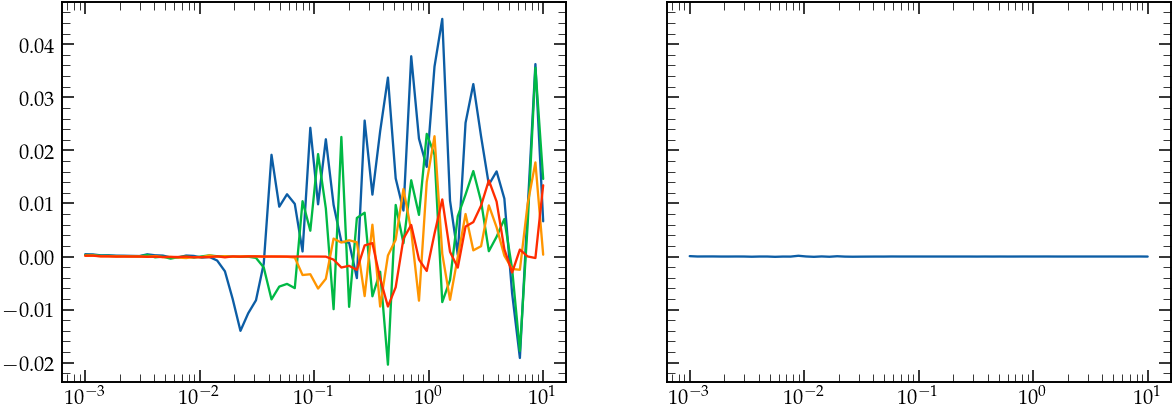

In [14]:
a_t, base_grid = 1.0, {'strategy': 5, 'bpd': 100.0}
top = run(point_tag(5.0, a_t, 's5_bpd400'), accdm_params(5.0, a_t, {'strategy': 5, 'bpd': 400.0}))
base = run(point_tag(5.0, a_t, 's5_bpd100'), accdm_params(5.0, a_t, base_grid))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for bpd in (25.0, 50.0, 100.0, 200.0):
    rec = run(point_tag(5.0, a_t, 's5_bpd{:g}'.format(bpd)), accdm_params(5.0, a_t, {'strategy': 5, 'bpd': bpd}))
    ax[0].semilogx(K_PK, rec['pk'][0.0]/top['pk'][0.0] - 1, label='bpd {:g}'.format(bpd))
for tol in (1e-5, 1e-7):
    p = accdm_params(5.0, a_t, base_grid); p['tol_perturbations_integration'] = tol
    rec = run(point_tag(5.0, a_t, 's5_bpd100_tol{:g}'.format(tol)), p)
    ax[1].semilogx(K_PK, rec['pk'][0.0]/base['pk'][0.0] - 1, label='tol {:g}'.format(tol))
    print('tol {:g}: max|dP/P| vs default tol {:.2e}, sigma8 {:.2e}, {:.0f}s'.format(
        tol, np.max(np.abs(rec['pk'][0.0]/base['pk'][0.0] - 1)), abs(rec['sigma8']/base['sigma8'] - 1), rec['seconds']))
ax[0].set_title('a_t = 1: grid ladder vs 400 bins/decade'); ax[1].set_title('bpd 100: tighter tolerance vs default')
for a in ax: a.axhline(0, color='0.6', lw=0.8); a.set_xlabel('k [1/Mpc]'); a.legend(fontsize=8)
ax[0].set_ylabel('P / P_ref - 1'); fig.tight_layout()

Text(0, 0.5, 'H(50 bpd)/H(400 bpd) - 1')

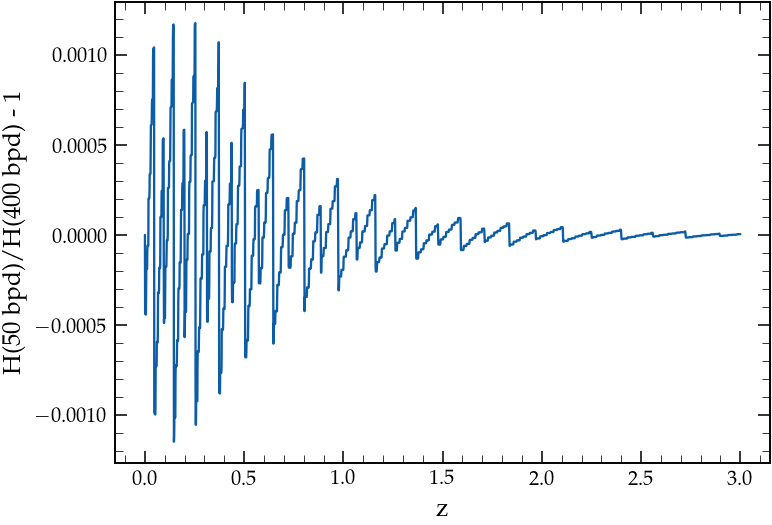

In [15]:
def H_of_z(grid, a_t=1.0):
    M = Class(); M.set(accdm_params(5.0, a_t, grid)); M.compute_background() if hasattr(M, 'compute_background') else M.compute(['background'])
    bg = M.get_background(); z, H = np.asarray(bg['z']), np.asarray(bg['H [1/Mpc]'])
    M.struct_cleanup(); M.empty(); return z[::-1], H[::-1]
z1, H1 = H_of_z({'strategy': 5, 'bpd': 50.0}); z2, H2 = H_of_z({'strategy': 5, 'bpd': 400.0})
zz = np.linspace(0, 3, 3000)
plt.plot(zz, np.interp(zz, z1, H1)/np.interp(zz, z2, H2) - 1); plt.xlabel('z'); plt.ylabel('H(50 bpd)/H(400 bpd) - 1')

## Reading the results

- **Part A passes** when strategy 5 matches the 501-bin strategy 4 against the 2001-bin reference,
  with no NaN and a ≥ 5× speed-up. If `S5 tol 1e-8` improves on `S5 default`, daughters born
  before a_min matter: lower `accdm_q_number_tol`. If `S5 50 bins/decade` improves, raise
  `accdm_q_bins_per_decade`.
- **Part B**: any NaN or failed run is a bug to report. Large S5 errors at one point mean the
  default density is too low for that κ / a_t; compare with the S4 column to check the fine
  reference itself.
- Not covered here: the daughter's own δ in the k-output columns before a_min. That path
  still divides by ρ = 0 (finding #13).